<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/PairsTrading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview
Built a cointegration-based pairs trading strategy to exploit mean-reverting relationships between correlated stocks.


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels as stat
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
stocks = yf.download(['GOOGL', 'MSFT', 'META', 'NVDA', 'AAPL','GS','MS'], start="2018-01-01",
    interval="1d"
)['Close']

stocks.head()
stocks.dropna()
stocks.info()

/tmp/ipykernel_531/1212505784.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(['GOOGL', 'MSFT', 'META', 'NVDA', 'AAPL','GS','MS'], start="2018-01-01",
[*********************100%***********************]  7 of 7 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2065 entries, 2018-01-02 to 2026-03-20
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2065 non-null   float64
 1   GOOGL   2065 non-null   float64
 2   GS      2065 non-null   float64
 3   META    2065 non-null   float64
 4   MS      2065 non-null   float64
 5   MSFT    2065 non-null   float64
 6   NVDA    2065 non-null   float64
dtypes: float64(7)
memory usage: 129.1 KB


we download the data for the stock prices on a dialy closing interval, For the Pair Tradding project.

**AIM - TO FIND COINTEGRATED STOCKS TO TRADE IN A PAIR TRADE**

In [ ]:
from statsmodels.tsa.stattools import coint
stocks = np.log(stocks)
# Test all pairs
pairs = ['AAPL', 'GOOGL', 'MSFT', 'META', 'GS', 'MS', 'NVDA']
for i in range(len(pairs)):
    for j in range(i+1, len(pairs)):
        s1 = stocks[pairs[i]]
        s2 = stocks[pairs[j]]
        score, pvalue, _ = coint(s1, s2)
        if pvalue < 0.05:
            print(f"COINTEGRATED: {pairs[i]} - {pairs[j]}, p={pvalue:.4f}")

COINTEGRATED: GOOGL - GS, p=0.0459


run cointrgration test on all pait to find a cointrgrated pair that we can trade on. GOOGL - GS are the cointegrated pairs.

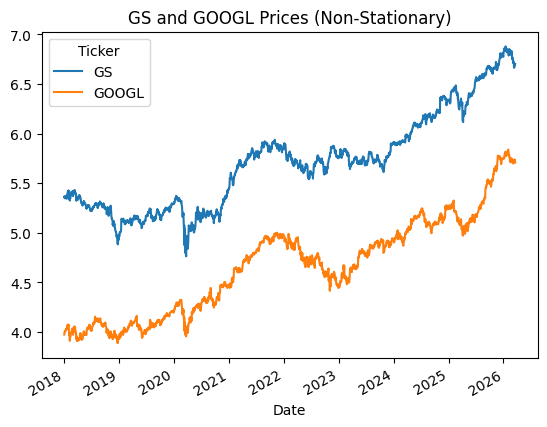

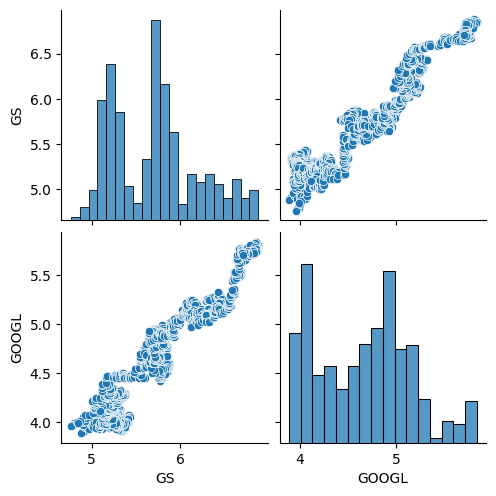

In [ ]:
stocks[['GS','GOOGL']].plot(title="GS and GOOGL Prices (Non-Stationary)")
plt.show()
sns.pairplot(stocks[["GS","GOOGL"]])

We plot curve and see the high correlation through th epiar plot and the line plot.  

In [ ]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series,name):
  result = adfuller(series)
  print(f"ADF Test STATS for {name} :", result[0])
  print("p_test value:", result[1])
  if result[1] < 0.05:
    print("Time series is stationary")
  else:
    print("Time series is non-stationary")

Creating a funtion to identify the non stationary Time series by appling the ADF test and using an additonal P-test if less than 0.05 then rejecting the unit Root hypothesis.

In [ ]:

  adf_test(stocks['GOOGL'], "Google")

  adf_test(stocks['GS'], "Goldman sacs")



ADF Test STATS for Google : 0.0840117503143298
p_test value: 0.964952396114207
Time series is non-stationary
ADF Test STATS for Goldman sacs : 0.06940468568426021
p_test value: 0.9639090525196653
Time series is non-stationary


Since the Time Series is Not-Stationary... we then  generate a spread by running a OLS test on the data.

In [ ]:
import statsmodels.api as sm
A = stocks['GOOGL']
B = stocks['GS']
B_const = sm.add_constant(B)
model = sm.OLS(A,B_const).fit()
alpha = model.params[0]
beta = model.params[1]
print("the value of alpha running OLS for min. error :", alpha)
print("the value of beta running OLS for min. error :", beta)


the value of alpha running OLS for min. error : -0.8037650551142401
the value of beta running OLS for min. error : 0.9573352128951811


/tmp/ipykernel_531/3072530073.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha = model.params[0]
/tmp/ipykernel_531/3072530073.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


OLS method we determine the best fitting aplha and beta, then minimise the spread or the error.

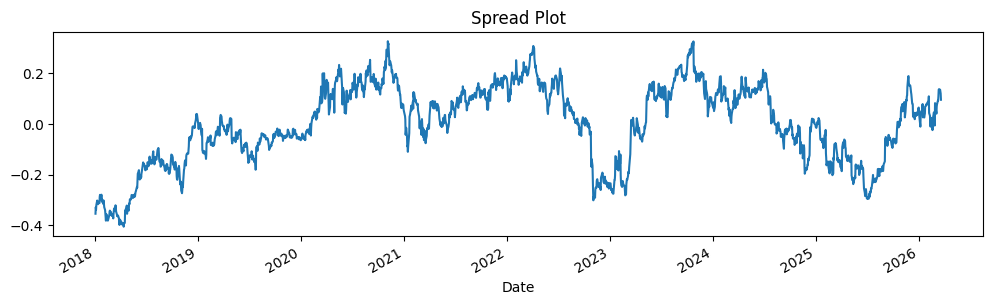

In [ ]:
spread = model.resid
spread = A - (alpha + beta*B)
spread.plot(figsize=(12,3))
plt.title("Spread Plot")
plt.show()

We plot the spread line graph and it look like a stationary curve, Constant Mean, Constant SD and not seasonality.

In [ ]:
adf_test(spread,"spread")

ADF Test STATS for spread : -3.368535500593924
p_test value: 0.012079417920581833
Time series is stationary


Running the test for spread stationary using the funtions that is already defined... SPREAD IS STATIONARY TIME SERIES.

[]

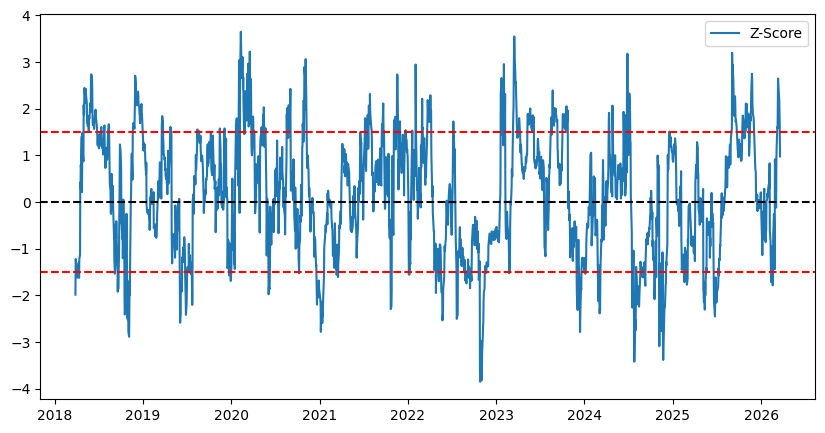

In [ ]:
window = 60
rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()
z_score = (spread - rolling_mean)/rolling_std
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(z_score, label="Z-Score")
plt.axhline(1.5,color = "r", linestyle="--")
plt.axhline(-1.5,color = "r", linestyle="--")
plt.axhline(0,color = "black", linestyle="--")
plt.legend()
plt.plot()



Even though the time series is stationary there are massive fluctations and the mean might turn out irrelevant for different time frames. thus we rolling mean and SD for a window of 60 days to calaculate z score...

WHY DO WE CALCULATE Z-SCORE?

BECAUSE OF THE FACT THAT WE DONT KNOW WHAT FLUCTATIONS IN THE TIME SEREIS ARE NORMAL AND WHAT ARE ABNORMALS... SO BY CALACUTING THE Z SCORE WE CAN SEE THE EXTREME HIGH FLUCTION FROM THE AVG FLUCTATIONS.

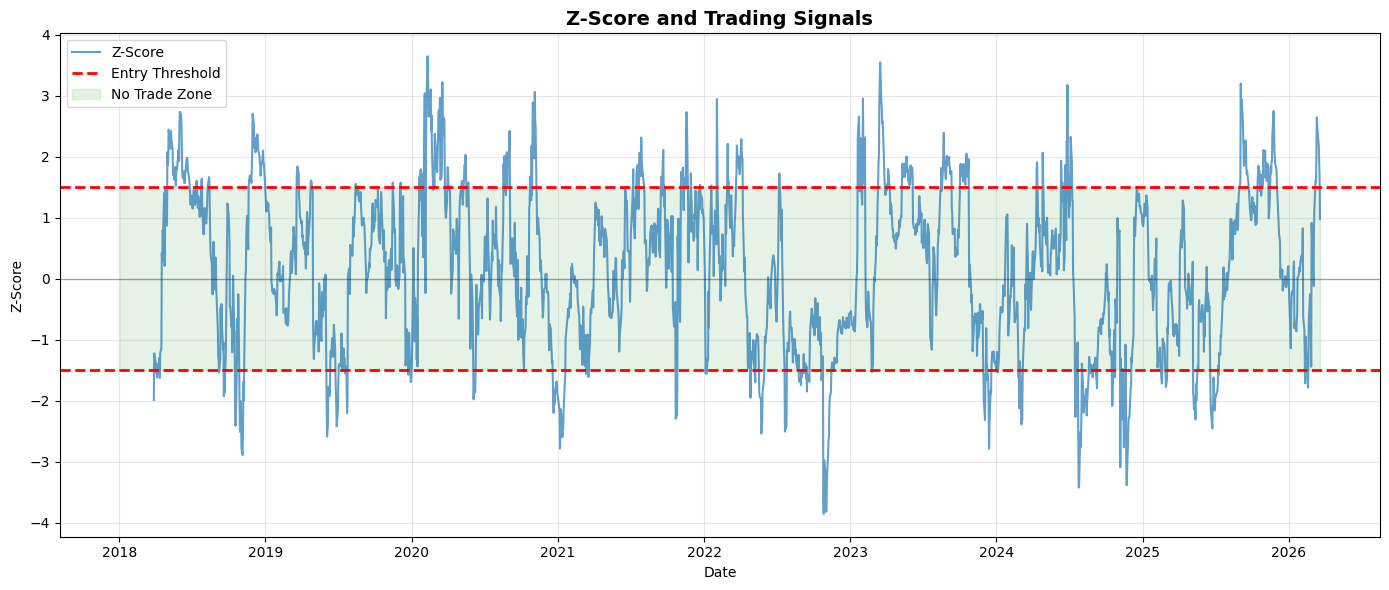

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(z_score.index, z_score, label='Z-Score', alpha=0.7, linewidth=1.5)
plt.axhline(1.5, color='r', linestyle='--', label='Entry Threshold', linewidth=2)
plt.axhline(-1.5, color='r', linestyle='--', linewidth=2)
plt.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.fill_between(z_score.index, -1.5, 1.5, alpha=0.1, color='green', label='No Trade Zone')
plt.title('Z-Score and Trading Signals', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*The extremely high fluctions are the ones where actual mis-pricing takes place and  that is where we can take postion and hold to earn profit....
if Z score is above 1.5 than we sell as the share A is overpriced and if the z score is below -1.5 than we buy A as it is relatively underpriced.... we do the oppsite with the share B and buy betaB and in the latter case we sell betaB*

In [ ]:

import pandas as pd

signals = pd.DataFrame(index=z_score.index)
signals['z'] = z_score

signals['signal'] = 0
signals.loc[signals['z'] > 1.5, 'signal'] = -1   # short spread
signals.loc[signals['z'] < -1.5, 'signal'] = 1   # long spread
signals['position'] = signals['signal'].replace(0, np.nan).fillna(method='ffill').fillna(0) # hold
signals.loc[signals['z'].abs() == 0, 'position'] = 0 # exit

# Fix PnL — use RAW prices not log prices
raw_stocks = np.exp(stocks)  # undo log transform

position_size = 100000
prices = pd.DataFrame({
    'GOOGL': raw_stocks['GOOGL'],
    'GS': raw_stocks['GS'],
    'position': signals['position']
}).dropna()

prices['ret_A'] = prices['GOOGL'].pct_change()
prices['ret_B'] = prices['GS'].pct_change()
prices['position_lag'] = prices['position'].shift(1)
prices['pnl'] = (
    prices['position_lag']
    * position_size
    * (prices['ret_A'] - beta * prices['ret_B'])
)
prices = prices.dropna()

/tmp/ipykernel_531/3605006638.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  signals['position'] = signals['signal'].replace(0, np.nan).fillna(method='ffill').fillna(0) # hold


In [ ]:
trade_changes = signals['position'].diff().fillna(0)
num_trades = (trade_changes != 0).sum()
print("Number of trades taken:", num_trades)

Number of trades taken: 32


**There have been a few error in thi spahse of the project intialiy my z score requiremnt was 2 which was too conservative and i didnt make any returns so now its 1.5 and the positions turns to 0 only then the Zscore absolute value turns to 0.**

signals.loc[signals['z'] > 1.5, 'signal'] = -1   # short spread
signals.loc[signals['z'] < -1.5, 'signal'] = 1   # long spread

we enter  with a buy when z score is less than 1.5. and vice a versa and exit when z score reaches 0.

This is a simple step.. u get a base dataframe with closing price and postion we took in the previous code block... we calutae the returns by pct.change for each stock to claculate the p&l... we create a position lag and where our todays trade equals tommorows p&l then we put the entire p&l formula to claute the p&l.
**to backtest i used backtesting.py software before but i only consdcuted 2 tardes and had a retrun of 0 why as it only conducted one postions at a time while we were coduction 2 a buy and a sell. and why only two trades god-knows**

In [ ]:

initial_capital = 1_000_000
prices['equity'] = initial_capital + prices['pnl'].cumsum()
prices['peak'] = prices['equity'].cummax()
prices['drawdown'] = prices['equity'] - prices['peak']
prices['drawdown_pct'] = prices['drawdown'] / prices['peak']



this is the part where we anaylse performance and calculate every aspects of the curve. total equity... peak, brakdown and breakbown pct

In [ ]:
daily_returns = prices['pnl'] / initial_capital


sharpe = (
    np.sqrt(252)
    * daily_returns.mean()
    / daily_returns.std()
)
total_return = (prices['equity'].iloc[-1] / initial_capital - 1) * 100
max_dd = prices['drawdown_pct'].min() * 100

print("Total Return %:", round(total_return, 2))
print("Sharpe Ratio :", round(sharpe, 2))
print("Max Drawdown %:", round(max_dd, 2))


Total Return %: 13.95
Sharpe Ratio : 0.55
Max Drawdown %: -4.07


final performance metrics are clalculated using sharpe ratio for the risk metrics and the retuns for the performance metric.

Total Return %: 13.95,
Sharpe Ratio : 0.55


 we had a breakdown of perfomance of 4.1 that means we could have been that much in profit on top of 13.95 but no worries.
 max drawdown of -4.1% is EXCELLENT (most strategies have 10-20%)

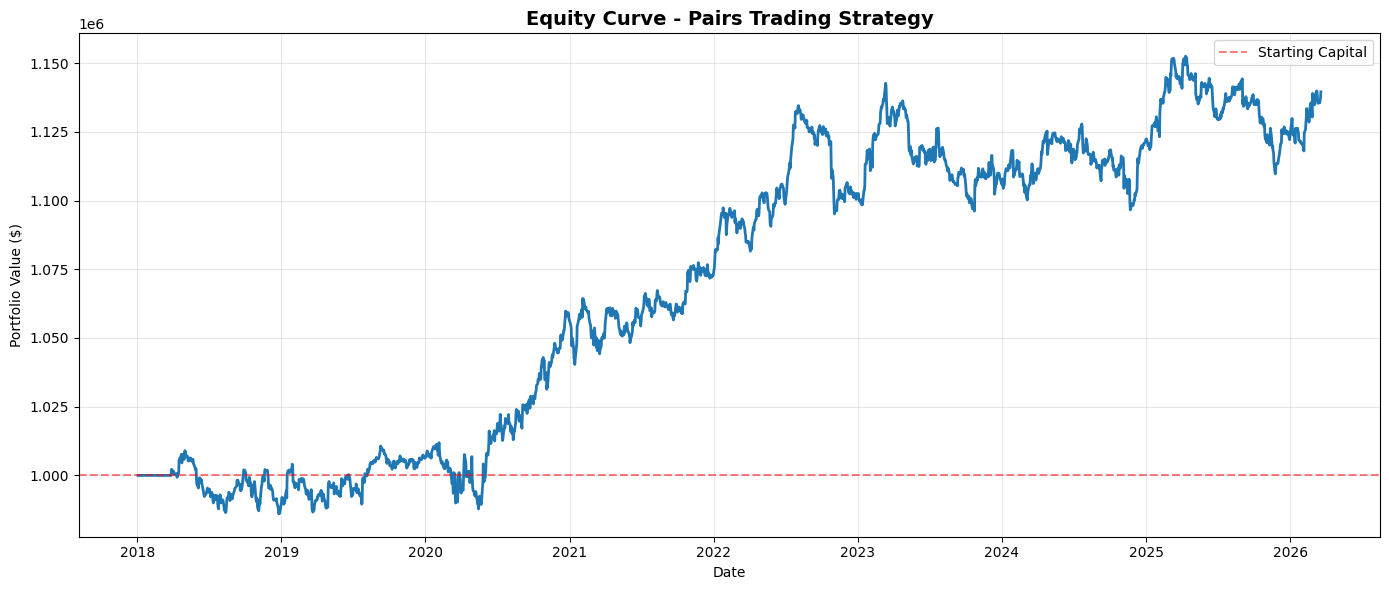

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(prices.index, prices['equity'], linewidth=2)
plt.axhline(initial_capital, color='r', linestyle='--', alpha=0.5, label='Starting Capital')
plt.title('Equity Curve - Pairs Trading Strategy', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plot showing the performance of thr curve overtime...
PROJECT COMPLETE 🥳